In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize'   : (9, 5),
    'figure.dpi'       : 120,
    'axes.titlesize'   : 14,
    'axes.titlepad'    : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'ytick.labelsize'  : 10,
    'xtick.labelsize'  : 10,
})
data = r'D:\Unsupervised_lab\retail-unsupervised-lab\data\Online Retail - Online Retail.csv'
df = pd.read_csv(data)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# DATA UNDERSTANDING

In [2]:
print(f'Shape : {df.shape[0]} rows x {df.shape[1]} columns')
print('Columns :')
print(df.dtypes.to_string())

Shape : 541909 rows x 8 columns
Columns :
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
Purchase_by_country = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)
Purchase_by_country.head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: InvoiceNo, dtype: int64

# DATA CLEANING

In [6]:
dup_counts = df.duplicated().sum()
if dup_counts > 0:
    df = df.drop_duplicates()
    print(f'Duplicates Removed. New Shape : {df.shape}')
else:
    print('No Duplicates , Dataset Is Clean.')

Duplicates Removed. New Shape : (536641, 8)


In [7]:
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_pct}).sort_values(by='Missing Values', ascending=False)
print(missing_data.to_string())

             Missing Values  Percentage
CustomerID           135037   25.163377
Description            1454    0.270945
StockCode                 0    0.000000
InvoiceNo                 0    0.000000
Quantity                  0    0.000000
InvoiceDate               0    0.000000
UnitPrice                 0    0.000000
Country                   0    0.000000


In [8]:
before = len(df)
df   = df.dropna(subset=['CustomerID'])
after  = len(df)
print(f'Rows removed (no CustomerID): {before - after}')
print(f'Remaining rows              : {after}')

Rows removed (no CustomerID): 135037
Remaining rows              : 401604


In [9]:
before = len(df)
df   = df[df['Quantity']  > 0]
df   = df[df['UnitPrice'] > 0]
after  = len(df)
print(f'Invalid transactions removed : {before - after}')
print(f'Remaining rows               : {after}')

Invalid transactions removed : 8912
Remaining rows               : 392692


In [10]:
num_cols = ['Quantity', 'UnitPrice']
outliers_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': len(outliers),
        'Outliers Percentage': (len(outliers) / len(df)) * 100
    })
outliers_df = pd.DataFrame(outliers_summary)
print(outliers_df.to_string())
print(f'\ntotal outliers detected : {outliers_df["Outliers Count"].sum()}')

      Column  Lower Bound  Upper Bound  Outliers Count  Outliers Percentage
0   Quantity        -13.0         27.0           25616             6.523178
1  UnitPrice         -2.5          7.5           34112             8.686706

total outliers detected : 59728


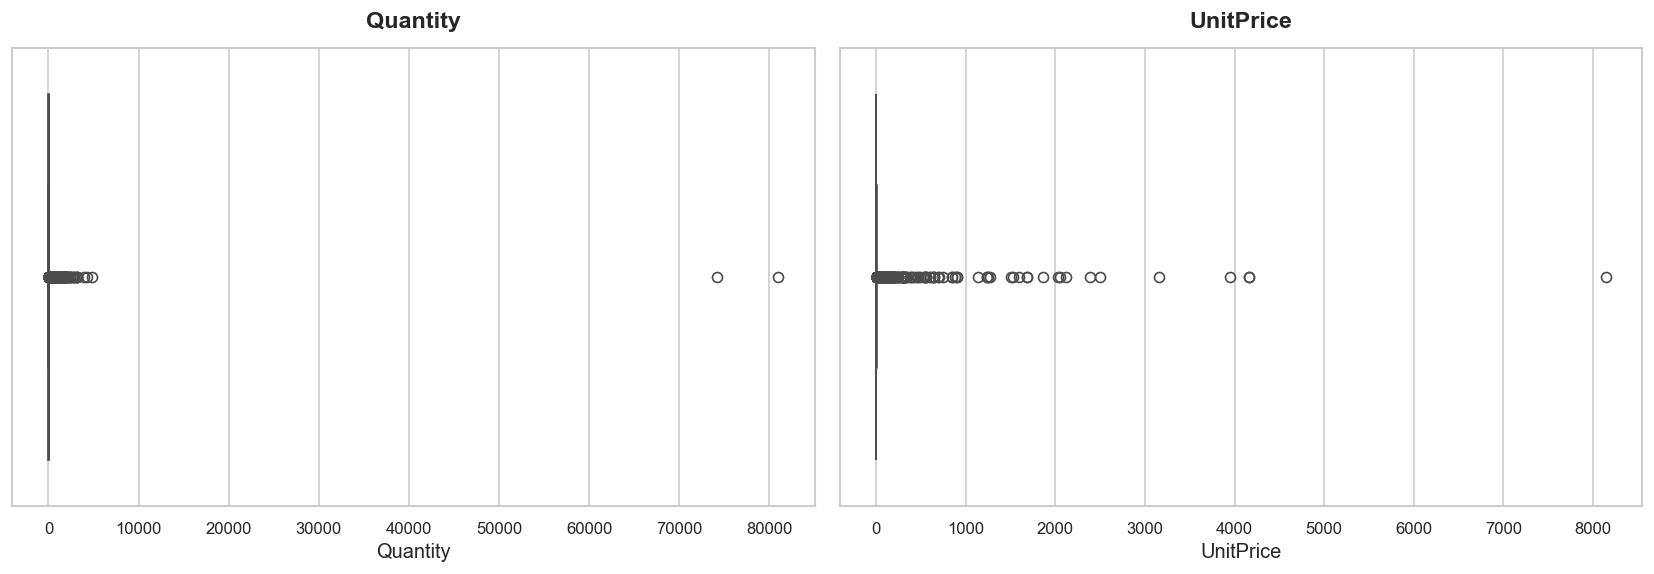

In [11]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Feature Engineering — RFM Calculation

In [12]:
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Reference date = 1 day after the last invoice in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalSpend',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'RFM table shape: {rfm.shape[0]} customers x {rfm.shape[1]} columns')
rfm.head(10)

RFM table shape: 4338 customers x 4 columns


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


## EDA (Exploratory Data Analysis)

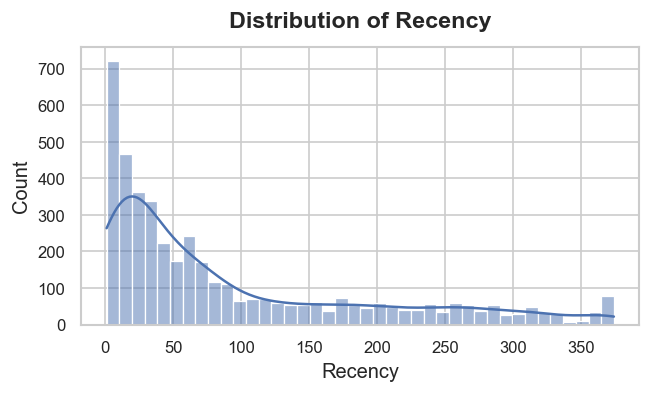

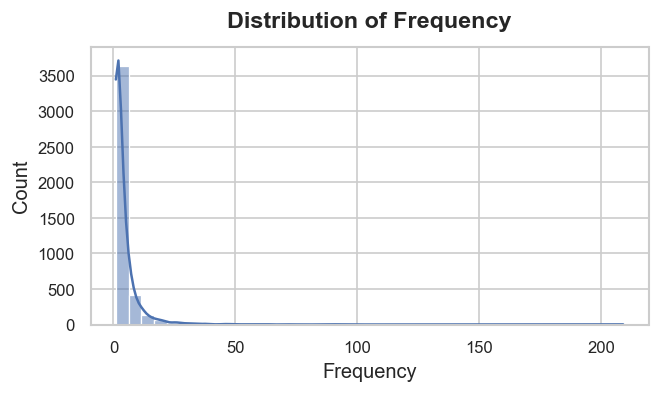

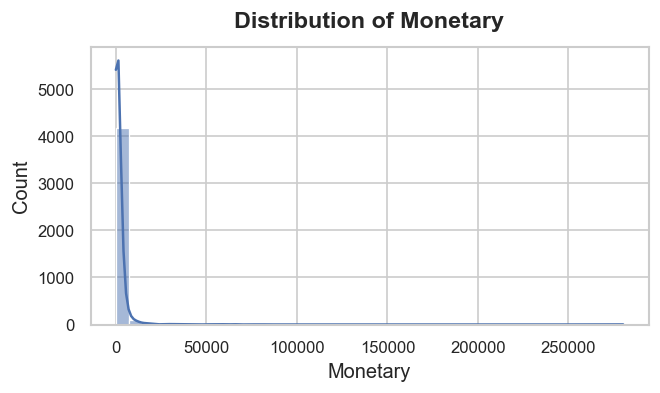

In [13]:
rfm_cols = ['Recency', 'Frequency', 'Monetary']

for col in rfm_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(rfm[col], kde=True, bins=40)
    plt.title(f'Distribution of {col}')
    plt.show()

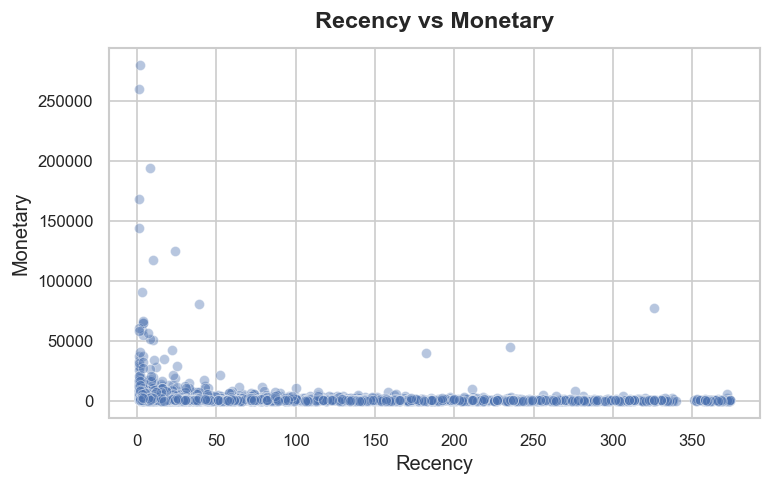

In [14]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Recency', y='Monetary', data=rfm, alpha=0.4)
plt.title('Recency vs Monetary')
plt.show()

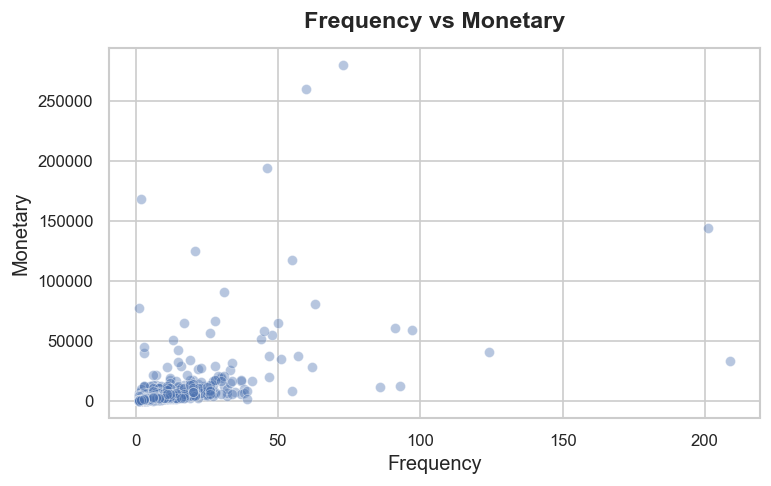

In [15]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Frequency', y='Monetary', data=rfm, alpha=0.4)
plt.title('Frequency vs Monetary')
plt.show()


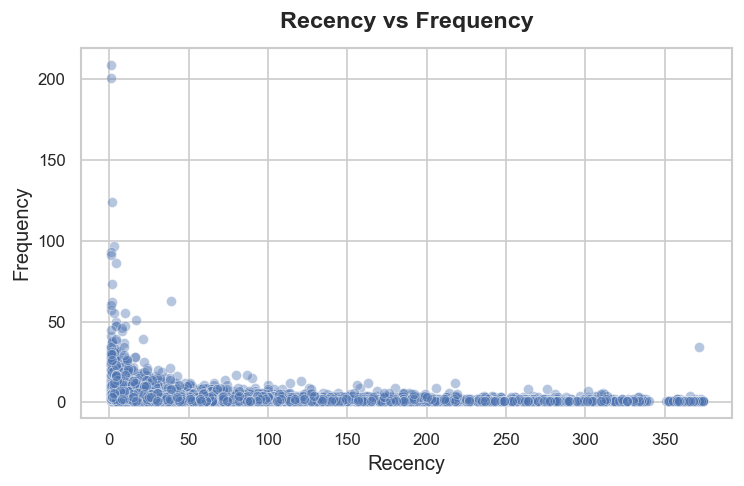

In [16]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Recency', y='Frequency', data=rfm, alpha=0.4)
plt.title('Recency vs Frequency')
plt.show()

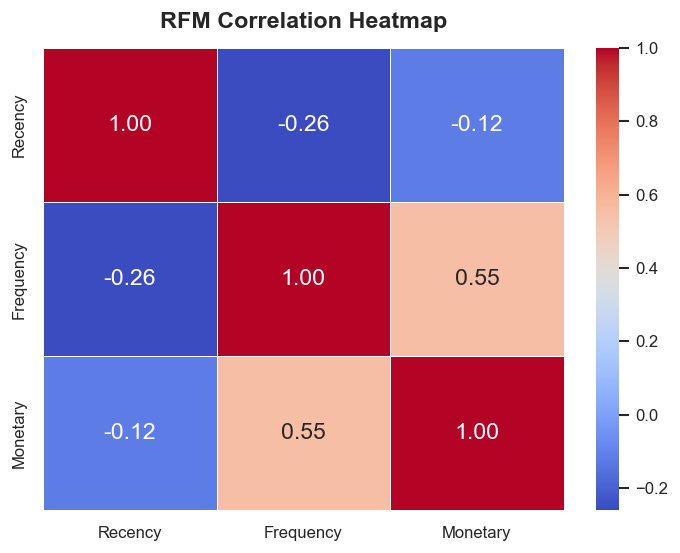

In [17]:
plt.figure(figsize=(7, 5))
corr = rfm[rfm_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('RFM Correlation Heatmap')
plt.show()

## preprocessing


In [18]:
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

print('RFM after Log Transformation:')
rfm_log[rfm_cols].describe().round(3)

RFM after Log Transformation:


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,3.831,1.346,6.589
std,1.340,0.683,1.258
min,0.693,0.693,1.558
25%,2.944,0.693,5.728
50%,3.951,1.099,6.507
75%,4.963,1.792,7.416
max,5.927,5.347,12.543


In [19]:
scaler    = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[rfm_cols])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_cols)

print('RFM after Scaling:')
rfm_scaled.describe().round(3)


RFM after Scaling:


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-3.998
25%,-0.661,-0.955,-0.684
50%,0.090,-0.362,-0.065
75%,0.845,0.653,0.657
max,1.564,5.859,4.732


## Finding Optimal Number of Clusters


Elbow Method


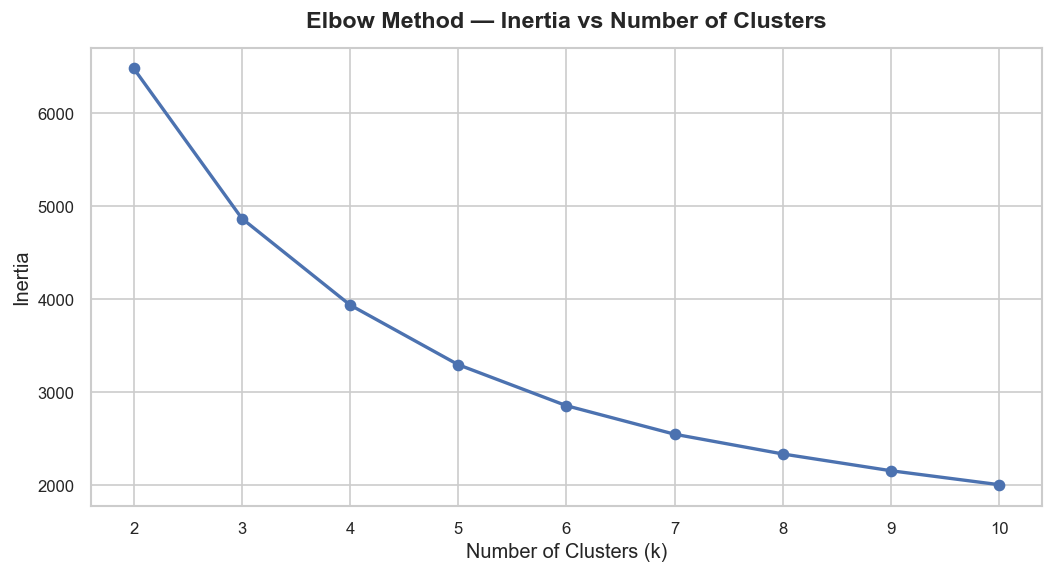

In [20]:
k_range  = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2)
plt.title('Elbow Method — Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Silhoute Score

In [21]:
sil_scores = []
db_scores  = []
ch_scores  = []

for k in k_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))
    ch_scores.append(calinski_harabasz_score(rfm_scaled, labels))

metrics_df = pd.DataFrame({
    'k'                  : list(k_range),
    'Silhouette Score'   : [round(s, 4) for s in sil_scores],
    'Davies-Bouldin'     : [round(d, 4) for d in db_scores],
    'Calinski-Harabasz'  : [round(c, 2) for c in ch_scores]
})
print(metrics_df.to_string(index=False))

 k  Silhouette Score  Davies-Bouldin  Calinski-Harabasz
 2            0.4328          0.8925            4367.32
 3            0.3365          1.0483            3625.30
 4            0.3375          1.0086            3328.34
 5            0.3162          0.9878            3192.98
 6            0.3124          1.0210            3081.89
 7            0.3092          0.9823            2963.79
 8            0.3033          0.9892            2827.07
 9            0.2811          1.0193            2725.20
10            0.2767          1.0268            2639.29


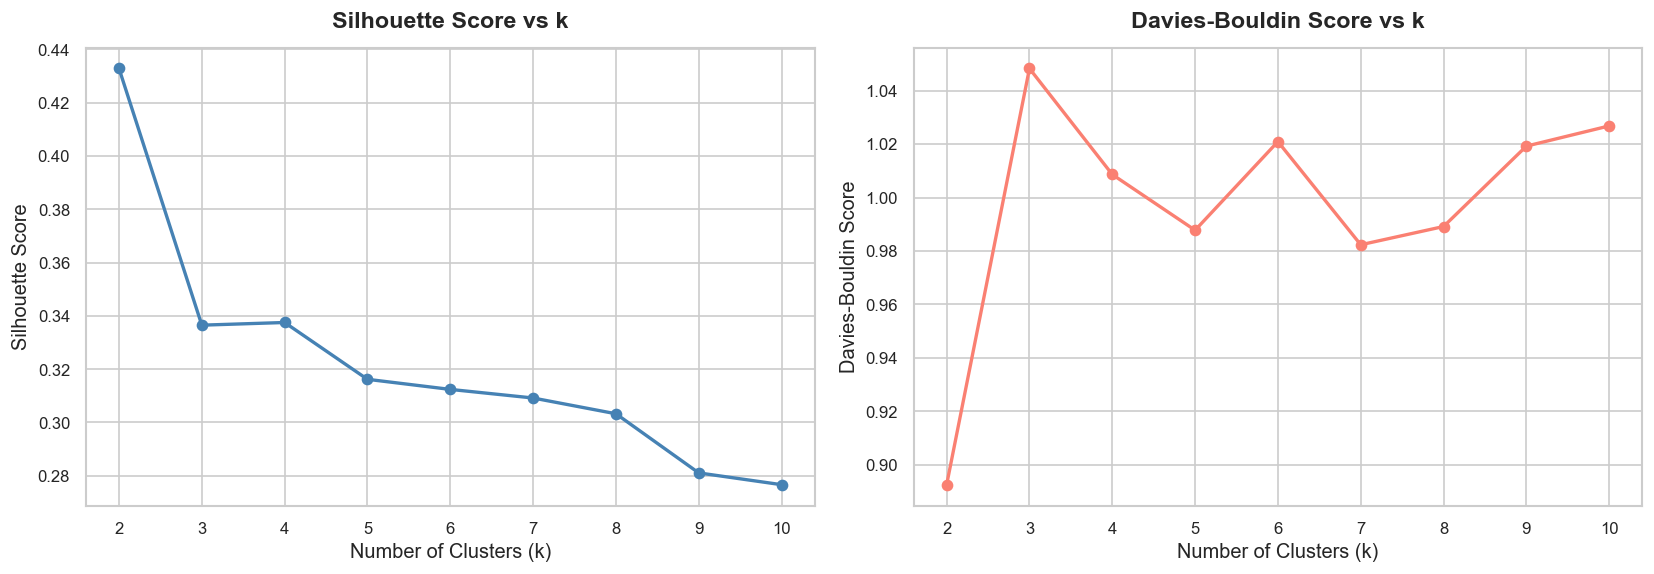

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sil_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, db_scores, marker='o', color='salmon', linewidth=2)
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

## K-Means Clustering (k = 4)

In [ ]:
# Silhouette peaks at k=2, but we use k=4 for a richer, business-interpretable
# segmentation (Champions / Loyal / New / Hibernating).
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'Customers per cluster (k={k}):')
print(rfm['Cluster'].value_counts().sort_index().to_string())

## Segment Profiling & Labelling

In [ ]:
profile = rfm.groupby('Cluster')[rfm_cols].mean()

# Highest / lowest spenders
champions   = profile['Monetary'].idxmax()
hibernating = profile['Monetary'].idxmin()

# Of the two remaining clusters: loyal = buys most often, new = the leftover
remaining = profile.drop(index=[champions, hibernating])
loyal     = remaining['Frequency'].idxmax()
new       = remaining.drop(index=loyal).index[0]

segments_map = {
    champions   : 'Champions',
    hibernating : 'Hibernating',
    loyal       : 'Loyal Customers',
    new         : 'New Customers',
}

rfm['Segment'] = rfm['Cluster'].map(segments_map)

print('Cluster Profiles (mean RFM):')
print(profile.round(2).to_string())
print()
print('Segment Mapping:')
for cluster_id, name in segments_map.items():
    print(f'  Cluster {cluster_id} -> {name}')
print()
print('Segment Distribution:')
print(rfm['Segment'].value_counts().to_string())